#### Import Libraries

In [58]:
import pandas as pd
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
load_dotenv()



True

In [59]:
# Example: call a Kimi-K3 model via the Hugging Face Inference API
# Set environment variable HF_API_TOKEN with your Hugging Face token before running
import os, requests, json
HF_MODEL = "audnai/penclaw-Kimi-K3.0-abliterated-GGUF"  # replace with the exact model id you want
HF_TOKEN = os.environ.get('HF_API_TOKEN')
if not HF_TOKEN:
    raise RuntimeError('Set the HF_API_TOKEN environment variable to call the HF Inference API')
headers = {'Authorization': f'Bearer {HF_TOKEN}'}
# Respect system proxy env vars if present (HTTP_PROXY / HTTPS_PROXY)
proxies = {}
http_proxy = os.environ.get('HTTP_PROXY') or os.environ.get('http_proxy')
https_proxy = os.environ.get('HTTPS_PROXY') or os.environ.get('https_proxy')
if http_proxy:
    proxies['http'] = http_proxy
if https_proxy:
    proxies['https'] = https_proxy

def hf_infer(model_id, input_text, timeout=120):
    url = f'https://api-inference.huggingface.co/models/{model_id}'
    payload = {'inputs': input_text, 'options': {'wait_for_model': True}}
    try:
        if proxies:
            r = requests.post(url, headers=headers, json=payload, timeout=timeout, proxies=proxies)
        else:
            r = requests.post(url, headers=headers, json=payload, timeout=timeout)
        r.raise_for_status()
    except requests.exceptions.RequestException as e:
        raise RuntimeError(
            f'Network error calling Hugging Face Inference API: {e}. '
            'Check DNS, proxy, VPN, or set HTTP(S)_PROXY environment variables if required.'
        ) from e
    out = r.json()
    if isinstance(out, dict) and out.get('error'):
        raise RuntimeError(out['error'])
    if isinstance(out, list):
        first = out[0]
        return first.get('generated_text', str(first))
    return str(out)

# Run the HF Kimi-K3 model on one sample patient (uses proxies if set)
example_patient = sample_patients.iloc[0]
example_text = serialize_patient(example_patient)
print('Calling HF Kimi-K3 model...')
try:
    response_text = hf_infer(HF_MODEL, example_text)
    print('Kimi-K3 response:')
    print(response_text)
except RuntimeError as e:
    print('Error while calling Hugging Face Inference API:')
    print(e)
    print('If this is a network/DNS error, consider running the model locally via GGUF and llama.cpp (see next cell).')

Calling HF Kimi-K3 model...
Error while calling Hugging Face Inference API:
Network error calling Hugging Face Inference API: HTTPSConnectionPool(host='api-inference.huggingface.co', port=443): Max retries exceeded with url: /models/audnai/penclaw-Kimi-K3.0-abliterated-GGUF (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002A0883B74D0>: Failed to resolve 'api-inference.huggingface.co' ([Errno 11001] getaddrinfo failed)")). Check DNS, proxy, VPN, or set HTTP(S)_PROXY environment variables if required.
If this is a network/DNS error, consider running the model locally via GGUF and llama.cpp (see next cell).


#### Strucutre for data

In [60]:
class StrokePrediction(BaseModel):
    reasoning: str = Field(description="Step-by-step clinical reasoning explaining the patient's risk.")
    prediction: int = Field(description="Final binary prediction: 1 (high stroke risk) or 0 (low risk).")

#### Function for serialize patient data

In [61]:
def serialize_patient(row: pd.Series) -> str:
    """Convert a dataset row into a natural-language patient profile."""

    return f"""
    Patient Profile:
    - Age: {row['age']} years
    - Gender: {row['gender']}
    - BMI (Body Mass Index): {row['bmi']}
    - Average glucose level: {row['avg_glucose_level']} mg/dL
    - Hypertension: {'Yes' if row['hypertension'] == 1 else 'No'}
    - Heart Disease: {'Yes' if row['heart_disease'] == 1 else 'No'}
    - Marital status (Ever married): {row['ever_married']}
    - Work type: {row['work_type']}
    - Residence type: {row['Residence_type']}
    - Smoking status: {row['smoking_status']}
    """

In [62]:
# Initialize the LLM
llm = ChatOpenAI(model="gpt-4o", temperature=0.0, api_key=os.environ.get("OPENAI_API_KEY"))

# Force structured output
structured_llm = llm.with_structured_output(StrokePrediction)

# Create the prompt template
prompt = PromptTemplate.from_template(
    """You are an expert medical analyst. Your task is to assess the risk of the following patient suffering a stroke.

    Carefully analyze their health metrics, lifestyle, and demographic data.
    Consider the interactions between age, hypertension, glucose levels, and BMI.

    {patient_data}
    """
)

# Build the execution chain
prediction_chain = prompt | structured_llm

#### Load and prepare data

In [63]:
# Load and prepare a sample of the data
df = pd.read_csv(r"D:\ML-AI\ai-on-healthcare\hw6\data\healthcare-dataset-stroke-data.csv")

# Quick basic imputation for the example
df['bmi'] = df['bmi'].fillna(df['bmi'].median())


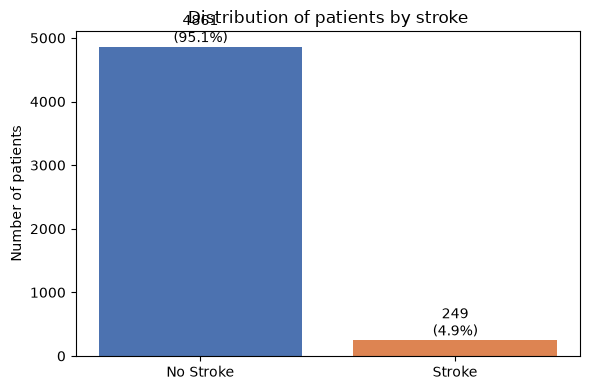

In [64]:
import matplotlib.pyplot as plt

counts = df['stroke'].value_counts().sort_index()
labels = ['No Stroke', 'Stroke']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=['#4c72b0', '#dd8452'])
ax.set_ylabel('Number of patients')
ax.set_title('Distribution of patients by stroke')

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, count, f'{count}\n({count/len(df):.1%})',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### Zero-shot prediction

In [65]:
# Select 10 random patients and predict stroke risk
sample_patients = df.sample(n=50, random_state=42)

predictions = []
for idx, patient_row in sample_patients.iterrows():
    patient_text = serialize_patient(patient_row)
    result = prediction_chain.invoke({"patient_data": patient_text})
    predictions.append({
        "index": idx,
        "predicted_stroke": result.prediction,
        "actual_stroke": int(patient_row['stroke']),
        "reasoning": result.reasoning,
    })

# Show summary
pred_df = pd.DataFrame(predictions)
print(pred_df[['predicted_stroke', 'actual_stroke']].head())

# Compare predictions with ground truth
confusion = pd.crosstab(pred_df['actual_stroke'], pred_df['predicted_stroke'], rownames=['actual'], colnames=['predicted'], dropna=False)
print("\nConfusion matrix (ground truth vs predicted):")
print(confusion)

accuracy = (pred_df['predicted_stroke'] == pred_df['actual_stroke']).mean()
precision = (pred_df[(pred_df['predicted_stroke'] == 1) & (pred_df['actual_stroke'] == 1)].shape[0] /
             max(pred_df[pred_df['predicted_stroke'] == 1].shape[0], 1))
recall = (pred_df[(pred_df['predicted_stroke'] == 1) & (pred_df['actual_stroke'] == 1)].shape[0] /
          max(pred_df[pred_df['actual_stroke'] == 1].shape[0], 1))

print("\nMetrics:")
print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

   predicted_stroke  actual_stroke
0                 0              0
1                 0              0
2                 0              0
3                 1              0
4                 0              0

Confusion matrix (ground truth vs predicted):
predicted   0   1
actual           
0          37  12
1           0   1

Metrics:
Accuracy: 76.00%
Precision: 7.69%
Recall: 100.00%


#### Few-shot prediction with examples

In [66]:
# Build a few-shot prompt using a handful of actual stroke patients
stroke_examples = df[df["stroke"] == 1].sample(n=3, random_state=42)

examples_text = "\n".join(
    f"Patient example:\n{serialize_patient(row)}- Known outcome: Stroke\n"
    for _, row in stroke_examples.iterrows()
)

prompt = PromptTemplate.from_template(
    """You are an expert medical analyst. Study these patient examples that were confirmed to have had a stroke.
Use the examples to understand how age, hypertension, glucose, BMI, heart disease, and lifestyle factors influence stroke risk.

Stroke-positive examples:
{examples}

Now assess the following new patient and provide:
- reasoning
- probability (0.0 to 1.0)
- prediction (1 for high stroke risk, 0 for low risk)

{patient_data}
"""
)

few_shot_prediction_chain = prompt | structured_llm
# add non-stroke examples and update the few-shot prompt/chain
non_stroke_examples = df[df["stroke"] == 0].sample(n=3, random_state=42)

stroke_examples = df[df["stroke"] == 1].sample(n=5, random_state=42)
non_stroke_examples = df[df["stroke"] == 0].sample(n=5, random_state=42)

stroke_examples_text = "\n".join(
    f"Patient example (Stroke):\n{serialize_patient(row)}- Known outcome: Stroke\n"
    for _, row in stroke_examples.iterrows()
)

non_examples_text = "\n".join(
    f"Patient example (No Stroke):\n{serialize_patient(row)}- Known outcome: No Stroke\n"
    for _, row in non_stroke_examples.iterrows()
)

examples_text = stroke_examples_text + "\n" + non_examples_text

prompt = PromptTemplate.from_template(
    """You are an expert medical analyst. Study these patient examples that were confirmed to have had a stroke, and these confirmed NOT to have had a stroke.
Use both kinds of examples to understand how age, hypertension, glucose, BMI, heart disease, and lifestyle factors influence stroke risk.

Examples:
{examples}

Now assess the following new patient and provide:
- reasoning
- probability (0.0 to 1.0)
- prediction (1 for high stroke risk, 0 for low risk)

{patient_data}
"""
)

few_shot_prediction_chain = prompt | structured_llm
print("Stroke examples used in the prompt:\n")
for i, (_, row) in enumerate(stroke_examples.iterrows(), start=1):
    print(f"Example {i}:\n{serialize_patient(row)}- Known outcome: Stroke\n")

# Run one sample prediction with the new few-shot prompt
test_patient = sample_patients.iloc[0]
result = few_shot_prediction_chain.invoke({"examples": examples_text, "patient_data": serialize_patient(test_patient)})
print("Prediction for one sample patient:")
print(result)

Stroke examples used in the prompt:

Example 1:

    Patient Profile:
    - Age: 76.0 years
    - Gender: Female
    - BMI (Body Mass Index): 34.9
    - Average glucose level: 207.28 mg/dL
    - Hypertension: No
    - Heart Disease: No
    - Marital status (Ever married): Yes
    - Work type: Private
    - Residence type: Urban
    - Smoking status: Unknown
    - Known outcome: Stroke

Example 2:

    Patient Profile:
    - Age: 74.0 years
    - Gender: Male
    - BMI (Body Mass Index): 27.4
    - Average glucose level: 70.09 mg/dL
    - Hypertension: Yes
    - Heart Disease: Yes
    - Marital status (Ever married): Yes
    - Work type: Private
    - Residence type: Rural
    - Smoking status: never smoked
    - Known outcome: Stroke

Example 3:

    Patient Profile:
    - Age: 58.0 years
    - Gender: Male
    - BMI (Body Mass Index): 31.4
    - Average glucose level: 240.59 mg/dL
    - Hypertension: No
    - Heart Disease: Yes
    - Marital status (Ever married): Yes
    - Work type:

#### Few-shot evaluation

In [67]:
# Few-shot metrics: run few-shot chain over sample_patients and compute metrics
fs_predictions = []
for idx, patient_row in sample_patients.iterrows():
    res = few_shot_prediction_chain.invoke({'examples': examples_text, 'patient_data': serialize_patient(patient_row)})
    fs_predictions.append({
        'index': idx,
        'predicted': res.prediction,
        'actual': int(patient_row['stroke']),
        'reasoning': res.reasoning,
    })
fs_df = pd.DataFrame(fs_predictions)
confusion_fs = pd.crosstab(fs_df['actual'], fs_df['predicted'], rownames=['actual'], colnames=['predicted'], dropna=False)
accuracy_fs = (fs_df['predicted'] == fs_df['actual']).mean()
precision_fs = (fs_df[(fs_df['predicted'] == 1) & (fs_df['actual'] == 1)].shape[0] / max(fs_df[fs_df['predicted'] == 1].shape[0],1))
recall_fs = (fs_df[(fs_df['predicted'] == 1) & (fs_df['actual'] == 1)].shape[0] / max(fs_df[fs_df['actual'] == 1].shape[0],1))
print('\nFew-shot Confusion Matrix:')
print(confusion_fs)
print(f'Few-shot Accuracy: {accuracy_fs:.2%}')
print(f'Few-shot Precision: {precision_fs:.2%}')
print(f'Few-shot Recall: {recall_fs:.2%}')


Few-shot Confusion Matrix:
predicted   0  1
actual          
0          46  3
1           1  0
Few-shot Accuracy: 92.00%
Few-shot Precision: 0.00%
Few-shot Recall: 0.00%
